In [1]:
!wget http://files.grouplens.org/datasets/movielens/ml-latest-small.zip

--2026-04-02 18:24:22--  http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-latest-small.zip [following]
--2026-04-02 18:24:23--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  4.33MB/s    in 0.2s    

2026-04-02 18:24:23 (4.33 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]



In [2]:
!unzip ml-latest-small.zip

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [3]:
!mv ml-latest-small/*.csv .

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [5]:

# Load Data
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")


In [6]:

# Clean Genres: Replace '|' with spaces so the Vectorizer can read them as words
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)

# Vectorize Genres
cv = CountVectorizer()
genre_matrix = cv.fit_transform(movies['genres'])

# Compute Cosine Similarity
# Formula: cos(theta) = (A.B) / (||A|| ||B||)
similarity = cosine_similarity(genre_matrix)

def recommend_movies_content(movie_title, n=5):
    try:
        # Get the index of the movie that matches the title
        idx = movies[movies['title'].str.contains(movie_title, case=False)].index[0]

        # Get pairwise similarity scores
        scores = list(enumerate(similarity[idx]))

        # Sort movies based on similarity scores
        scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]

        # Get the movie indices
        movie_indices = [i[0] for i in scores]

        print(f"Recommendations for: {movie_title}")
        return movies[['title', 'genres']].iloc[movie_indices]
    except IndexError:
        return "Movie not found. Please check the title spelling."

# Test it
recommend_movies_content("Toy Story (1995)")

/tmp/ipykernel_930/13384244.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  idx = movies[movies['title'].str.contains(movie_title, case=False)].index[0]


'Movie not found. Please check the title spelling.'

In [7]:
# Create User-Item Matrix
# Rows = UserID, Columns = MovieID, Values = Ratings
user_movie_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

# Compute Similarity between movies based on user ratings
movie_similarity = cosine_similarity(user_movie_matrix.T)
movie_sim_df = pd.DataFrame(movie_similarity, index=user_movie_matrix.columns, columns=user_movie_matrix.columns)

def collaborative_recommend(movie_id, n=5):
    if movie_id not in movie_sim_df.columns:
        return "Movie ID not found."

    # Get similar movies from the matrix
    similar_scores = movie_sim_df[movie_id].sort_values(ascending=False)[1:n+1]
    similar_movie_ids = similar_scores.index

    return movies[movies['movieId'].isin(similar_movie_ids)][['title', 'genres']]

# Test it (Movie ID 1 is Toy Story)
print("Collaborative Recommendations for Movie ID 1:")
collaborative_recommend(1)

Collaborative Recommendations for Movie ID 1:


,title,genres
224,Star Wars: Episode IV - A New Hope (1977),Action Adventure Sci-Fi
314,Forrest Gump (1994),Comedy Drama Romance War
418,Jurassic Park (1993),Action Adventure Sci-Fi Thriller
615,Independence Day (a.k.a. ID4) (1996),Action Adventure Sci-Fi Thriller
2355,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy


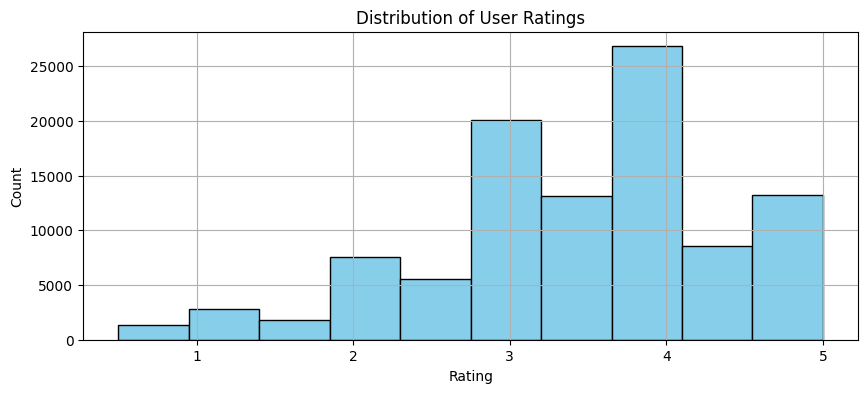

In [8]:
# Visualize rating distribution
plt.figure(figsize=(10,4))
ratings['rating'].hist(bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()